# Graph-based analysis of ACE dependency comments

Analyses implemented:

1. **Functional-group distribution** — about-plot vs beyond-plot vs normative, etc.
2. **Sequence analysis** — transition matrix over sentence-type groups in discourse order.
3. **Edge-type matrix** — top-down vs bottom-up influences in the dependency DAG.
4. **Node roles** — in-degree / out-degree by functional group; is normative an L5 sink?
5. **Attachment & distance-to-plot** — how tightly beyond-plot sentences are anchored to plot content.
6. **Comment-level heterogeneity** — per-comment integration strategies.
7. **Bayesian multilevel models** — within / between comment variation in integration.

Assumes `combined_data/181.json` is available.

In [8]:
from __future__ import annotations

import json
import warnings
from collections import Counter, defaultdict
from itertools import product
from pathlib import Path
from typing import Dict, List, Tuple

import altair as alt
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

# DATA_PATH = Path("combined_data") / "181.json"
DATA_PATH = Path("reduced_data") / "181.json"
with DATA_PATH.open() as f:
    comments: List[dict] = json.load(f)

print(f"Loaded {len(comments)} comments")

Loaded 153 comments


In [9]:
# !pip install seaborn

## 0 — Functional group mapping

| Group | Original categories | Theoretical role |
|---|---|---|
| `about_plot` | Visual feature detection, Visual data extraction, Encoding interpretation | Bottom-up: reading the chart (L1-L3) |
| `beyond_plot` | Background knowledge, Explanatory inference, Predictive / counterfactual inference, Information need / curiosity | Top-down / lateral: world knowledge and inference (L4) |
| `normative` | Evaluative / affective judgment | Candidate L5 |
| `personal` | Personal/episodic retrieval | Lived experience |
| `meta` | Meta / paratext | About the artifact |

In [10]:
TAG_TO_GROUP: Dict[str, str] = {
    "Visual feature detection": "about_plot",
    "Visual data extraction": "about_plot",
    "Encoding interpretation": "about_plot",
    "Background knowledge": "beyond_plot",
    "Explanatory inference": "beyond_plot",
    "Predictive / counterfactual inference": "beyond_plot",
    "Information need / curiosity": "beyond_plot",
    "Evaluative / affective judgment": "normative",
    "Personal/episodic retrieval": "personal",
    "Meta / paratext": "meta",
}
GROUPS = ["about_plot", "beyond_plot", "normative", "personal", "meta"]

def to_group(tag: str | None) -> str:
    if not tag:
        return "unknown"
    return TAG_TO_GROUP.get(tag, "unknown")

### Helper: build flat node/edge tables

In [11]:
node_rows = []
edge_rows = []

for c in comments:
    ci = c["comment_index"]
    nodes_by_id = {}
    for n in c.get("dependency_graph") or []:
        tag = n.get("comment_tag") or ""
        grp = to_group(tag)
        nodes_by_id[n["id"]] = grp
        node_rows.append({
            "comment_index": ci,
            "node_id": n["id"],
            "sentence": n["sentence"],
            "tag": tag,
            "group": grp,
            "cluster_id": n.get("cluster_id", ""),
            "cluster_statement": n.get("cluster_statement", ""),
            "in_degree": 0,
            "out_degree": len(n.get("depends_on") or []),
        })
    for n in c.get("dependency_graph") or []:
        for dep in n.get("depends_on") or []:
            src_grp = nodes_by_id.get(dep, "unknown")
            tgt_grp = nodes_by_id.get(n["id"], "unknown")
            edge_rows.append({
                "comment_index": ci,
                "source": dep,
                "target": n["id"],
                "src_group": src_grp,
                "tgt_group": tgt_grp,
            })

# patch in_degree
in_deg_counter: Dict[Tuple[int, int], int] = Counter()
for e in edge_rows:
    in_deg_counter[(e["comment_index"], e["target"])] += 1
for nr in node_rows:
    nr["in_degree"] = in_deg_counter.get((nr["comment_index"], nr["node_id"]), 0)

nodes_df = pd.DataFrame(node_rows)
edges_df = pd.DataFrame(edge_rows)

print(f"Nodes: {len(nodes_df)}, Edges: {len(edges_df)}")
nodes_df.head()

Nodes: 2011, Edges: 1970


,comment_index,node_id,sentence,tag,group,cluster_id,cluster_statement,in_degree,out_degree
0,1,0,The rate of wind energy and solar energy has i...,Visual data extraction,about_plot,S114,Wind power increases and solar power increases.,0,0
1,1,1,"However, fossil fuels occupy more than half of...",Visual data extraction,about_plot,S8,Fossil fuels are the majority or dominant sour...,0,0
2,1,2,This situation is a problem.,Evaluative / affective judgment,normative,S12,People have an unsustainable lifestyle and thi...,1,1
3,1,3,The governments of various countries promote r...,Background knowledge,beyond_plot,S6,The world is moving toward renewable or clean ...,2,2
4,1,4,"When I was a junior high school student, I had...",Personal/episodic retrieval,personal,S34,"When I was a junior high school student, I had...",1,1


## 1 — Distribution of functional groups

In [12]:
# A. Overall counts
grp_cts = nodes_df["group"].value_counts().reindex(GROUPS + ["unknown"]).dropna().astype(int).reset_index()
grp_cts.columns = ["group", "count"]
chart_a = alt.Chart(grp_cts).mark_bar(color="steelblue").encode(
    x=alt.X("group:N", sort=list(grp_cts["group"]), title=None),
    y=alt.Y("count:Q", title="# sentences"),
).properties(title="Sentence counts by functional group", width=350, height=250)

# B. Fine-grained tags
tag_cts = nodes_df["tag"].value_counts().reset_index()
tag_cts.columns = ["tag", "count"]
chart_b = alt.Chart(tag_cts).mark_bar(color="teal").encode(
    y=alt.Y("tag:N", sort="-x", title=None),
    x=alt.X("count:Q", title="# sentences"),
).properties(title="Sentence counts by original tag", width=350, height=250)

chart_a | chart_b

alt.HConcatChart(...)

In [13]:
# A. Overall counts - sort by count descending
grp_cts = (
    nodes_df["group"]
    .value_counts()
    .reindex(GROUPS + ["unknown"])
    .dropna()
    .astype(int)
    .reset_index()
    .sort_values("group")  # we will use label for sorting instead
)
grp_cts.columns = ["group", "count"]

# Append count at the start of the label to enforce sorting visually/lexically
grp_cts["group_label"] = grp_cts["count"].astype(str) + " — " + grp_cts["group"]

chart_a = alt.Chart(grp_cts).mark_bar(color="steelblue").encode(
    x=alt.X("group_label:N", sort=None, title=None),
    y=alt.Y("count:Q", title="# sentences"),
).properties(title="Sentence counts by functional group", width=350, height=250)

# B. Stacked bar: cluster_statement within each tag - sort tag by descending total count
cluster_stacked_df = (
    nodes_df.groupby(["tag", "cluster_statement"])
    .size()
    .reset_index(name="count")
)

# Calculate total count per tag to sort tags by descending total count
tag_total_counts = (
    cluster_stacked_df.groupby("tag")["count"].sum()
    .sort_values(ascending=False)
)
tag_order = list(tag_total_counts.index)

# Append count at the start of the cluster_statement label
cluster_stacked_df["cluster_statement_label"] = (
    cluster_stacked_df["count"].astype(str) + " — " + cluster_stacked_df["cluster_statement"]
)

# For color order by highest count first in each tag (flattened over all tags for color), get top cluster_statement counts:
color_counts = (
    cluster_stacked_df.groupby("cluster_statement_label")["count"].sum()
    .sort_values(ascending=False)
)
cluster_statement_order = list(color_counts.index)

chart_b_stacked = (
    alt.Chart(cluster_stacked_df)
    .mark_bar()
    .encode(
        y=alt.Y("tag:N", sort=tag_order, title=None),
        x=alt.X("count:Q", title="# sentences"),
        color=alt.Color(
            "cluster_statement_label:N", 
            sort=cluster_statement_order, 
            legend=alt.Legend(title="Cluster Statement")
        ),
        tooltip=["tag:N", "cluster_statement_label:N", "count:Q"]
    )
    .properties(title="Sentence counts by original tag (stacked by cluster_statement)", width=350, height=250)
)

chart_a | chart_b_stacked

alt.HConcatChart(...)

In [14]:
# Per-comment proportions
comment_props = (
    nodes_df.groupby(["comment_index", "group"]).size()
    .unstack(fill_value=0)
)
comment_props = comment_props.div(comment_props.sum(axis=1), axis=0)
comment_props.describe().round(3)

group,about_plot,beyond_plot,meta,normative,personal
count,153.000,153.000,153.000,153.000,153.000
mean,0.352,0.358,0.125,0.081,0.084
std,0.164,0.155,0.138,0.124,0.102
min,0.000,0.000,0.000,0.000,0.000
25%,0.250,0.250,0.062,0.000,0.000
50%,0.364,0.364,0.095,0.045,0.059
75%,0.462,0.444,0.143,0.125,0.133
max,0.833,0.800,1.000,1.000,0.500


In [15]:
cols = [c for c in GROUPS if c in comment_props.columns]
box_df = comment_props[cols].melt(var_name="group", value_name="proportion")

alt.Chart(box_df).mark_boxplot().encode(
    x=alt.X("group:N", sort=cols, title=None),
    y=alt.Y("proportion:Q", title="Proportion of sentences"),
).properties(title="Per-comment proportions of functional groups", width=500, height=300)

alt.Chart(...)

## 2 — Sequence (temporal-order) transition analysis

In [16]:
from itertools import product

# Compute count and probability transition matrices as before
transitions = Counter()
for c in comments:
    seq = [n.get("comment_tag") for n in sorted(c.get("dependency_graph") or [], key=lambda n: n["id"])]
    for a, b in zip(seq, seq[1:]):
        transitions[(a, b)] += 1

all_tags = sorted({g for pair in transitions for g in pair})
# Fill zeros for all pairs so the heatmap grid is complete
all_pairs = list(product(all_tags, all_tags))

heatmap_count_data = []
for a, b in all_pairs:
    cnt = transitions.get((a, b), 0)
    heatmap_count_data.append({"current": a, "next": b, "count": cnt})

trans_mat = pd.DataFrame(0, index=all_tags, columns=all_tags, dtype=int)
for (a, b), cnt in transitions.items():
    trans_mat.loc[a, b] = cnt

trans_row_sum = trans_mat.sum(axis=1).replace(0, np.nan)
heatmap_prob_data = []
for a, b in all_pairs:
    cnt = transitions.get((a, b), 0)
    denom = trans_row_sum[a]
    prob = cnt / denom if pd.notna(denom) and denom > 0 else np.nan
    heatmap_prob_data.append({"current": a, "next": b, "probability": prob})

# Transition count heatmap (row=current, col=next)
count_chart = (
    alt.Chart(pd.DataFrame(heatmap_count_data))
    .mark_rect()
    .encode(
        x=alt.X("next:O", title="Next", sort=all_tags),
        y=alt.Y("current:O", title="Current", sort=all_tags),
        color=alt.Color(
            "count:Q",
            scale=alt.Scale(scheme="blues"),
            legend=alt.Legend(title="Transition count"),
        ),
        tooltip=["current", "next", "count"]
    )
    .properties(
        title="Transition counts (row → col in discourse order)",
        width=300, height=300
    )
    +
    alt.Chart(pd.DataFrame(heatmap_count_data)).mark_text(baseline="middle").encode(
        x=alt.X("next:O", sort=all_tags),
        y=alt.Y("current:O", sort=all_tags),
        text=alt.Text("count:Q"),
        color=alt.condition(
            "datum.count < 100",
            alt.value("black"),
            alt.value("white"),
        )
    )
)

# Transition probability heatmap (row-normalised)
prob_chart = (
    alt.Chart(pd.DataFrame(heatmap_prob_data))
    .mark_rect()
    .encode(
        x=alt.X("next:O", title="Next", sort=all_tags),
        y=alt.Y("current:O", title="Current", sort=all_tags),
        color=alt.Color(
            "probability:Q",
            scale=alt.Scale(scheme="blues"),
            legend=alt.Legend(title="Transition probability"),
        ),
        tooltip=["current", "next", alt.Tooltip("probability:Q", format=".2f")]
    )
    .properties(
        title="Transition probabilities (row-normalised)",
        width=300, height=300
    )
    +
    alt.Chart(pd.DataFrame(heatmap_prob_data)).mark_text(baseline="middle").encode(
        x=alt.X("next:O", sort=all_tags),
        y=alt.Y("current:O", sort=all_tags),
        text=alt.Text("probability:Q", format=".2f"),
        color=alt.condition(
            "datum.probability < 0.4",
            alt.value("black"),
            alt.value("white"),
        )
    )
)

alt.hconcat(
    count_chart.resolve_scale(color="independent"),
    prob_chart.resolve_scale(color="independent")
)

alt.HConcatChart(...)

In [17]:
trigrams = Counter()
for c in comments:
    seq = [to_group(n.get("comment_tag")) for n in sorted(c.get("dependency_graph") or [], key=lambda n: n["id"])]
    for i in range(len(seq) - 2):
        trigrams[(seq[i], seq[i+1], seq[i+2])] += 1

print("Top 20 trigram motifs (discourse order):")
for motif, cnt in trigrams.most_common(20):
    print(f"  {' → '.join(motif):50s} {cnt}")

Top 20 trigram motifs (discourse order):
  about_plot → about_plot → about_plot               305
  beyond_plot → beyond_plot → beyond_plot            193
  about_plot → about_plot → beyond_plot              143
  about_plot → beyond_plot → beyond_plot             121
  beyond_plot → about_plot → about_plot              64
  about_plot → beyond_plot → about_plot              54
  beyond_plot → beyond_plot → meta                   51
  beyond_plot → beyond_plot → personal               46
  beyond_plot → beyond_plot → about_plot             40
  beyond_plot → about_plot → beyond_plot             38
  beyond_plot → beyond_plot → normative              37
  beyond_plot → personal → personal                  34
  beyond_plot → normative → beyond_plot              30
  beyond_plot → personal → beyond_plot               29
  personal → beyond_plot → beyond_plot               28
  meta → about_plot → about_plot                     25
  about_plot → beyond_plot → personal                25
  p

In [19]:
# Count trigrams (in discourse order) that end on a leaf node (node with out-degree zero)
trigrams_leaf = Counter()
for c in comments:
    dg = sorted(c.get("dependency_graph") or [], key=lambda n: n["id"])
    # Build id → out-degree mapping
    out_deg = {n["id"]: 0 for n in dg}
    for n in dg:
        for dep in n.get("depends_on", []):
            out_deg[dep] = out_deg.get(dep, 0) + 1
    # Get ordered list of nodes and tags
    seq_nodes = dg
    seq_tags = [to_group(n.get("comment_tag")) for n in seq_nodes]
    seq_ids = [n["id"] for n in seq_nodes]
    # Find all trigrams where last node is a leaf (out-degree 0)
    for i in range(len(seq_tags) - 2):
        third_id = seq_ids[i+2]
        if out_deg.get(third_id, 0) == 0:
            trigram = (seq_tags[i], seq_tags[i+1], seq_tags[i+2])
            trigrams_leaf[trigram] += 1

print("Top 20 trigrams ending on a leaf node (discourse order):")
for motif, cnt in trigrams_leaf.most_common(20):
    print(f"  {' → '.join(motif):50s} {cnt}")

Top 20 trigrams ending on a leaf node (discourse order):
  beyond_plot → beyond_plot → beyond_plot            106
  about_plot → about_plot → about_plot               99
  about_plot → beyond_plot → beyond_plot             70
  about_plot → about_plot → beyond_plot              62
  beyond_plot → beyond_plot → meta                   44
  beyond_plot → about_plot → about_plot              28
  beyond_plot → about_plot → beyond_plot             21
  beyond_plot → beyond_plot → normative              20
  beyond_plot → beyond_plot → personal               18
  normative → beyond_plot → meta                     17
  about_plot → beyond_plot → about_plot              16
  personal → beyond_plot → beyond_plot               15
  beyond_plot → normative → beyond_plot              15
  personal → beyond_plot → meta                      14
  beyond_plot → beyond_plot → about_plot             14
  normative → beyond_plot → beyond_plot              13
  personal → personal → beyond_plot           

### 2.1 Common trigram motifs in discourse order

We look at the most common 3-step patterns to see typical integration motifs.

In [36]:
trigrams = Counter()
for c in comments:
    seq = [to_group(n.get("comment_tag")) for n in sorted(c.get("dependency_graph") or [], key=lambda n: n["id"])]
    for i in range(len(seq) - 2):
        trigrams[(seq[i], seq[i+1], seq[i+2])] += 1

print("Top 20 trigram motifs (discourse order):")
for motif, cnt in trigrams.most_common(20):
    print(f"  {' → '.join(motif):50s} {cnt}")

Top 20 trigram motifs (discourse order):
  beyond_plot → beyond_plot → beyond_plot            437
  about_plot → about_plot → about_plot               434
  about_plot → about_plot → beyond_plot              161
  about_plot → beyond_plot → beyond_plot             154
  beyond_plot → about_plot → about_plot              80
  beyond_plot → beyond_plot → meta                   75
  meta → meta → meta                                 75
  beyond_plot → beyond_plot → about_plot             63
  beyond_plot → beyond_plot → personal               61
  about_plot → beyond_plot → about_plot              47
  beyond_plot → beyond_plot → normative              46
  beyond_plot → personal → personal                  44
  personal → beyond_plot → beyond_plot               39
  normative → beyond_plot → beyond_plot              38
  personal → personal → personal                     34
  beyond_plot → about_plot → beyond_plot             33
  personal → personal → beyond_plot                  31
  m

In [18]:
trigrams = Counter()
for c in comments:
    seq = [n.get("comment_tag") for n in sorted(c.get("dependency_graph") or [], key=lambda n: n["id"])]
    for i in range(len(seq) - 2):
        trigrams[(seq[i], seq[i+1], seq[i+2])] += 1

print("Top 20 trigram motifs (discourse order):")
for motif, cnt in trigrams.most_common(20):
    print(f"  {' → '.join(motif):50s} {cnt}")

Top 20 trigram motifs (discourse order):
  Visual data extraction → Visual data extraction → Visual data extraction 264
  Visual data extraction → Visual data extraction → Information need / curiosity 68
  Visual data extraction → Visual data extraction → Background knowledge 52
  Background knowledge → Visual data extraction → Visual data extraction 43
  Visual data extraction → Background knowledge → Visual data extraction 32
  Background knowledge → Background knowledge → Background knowledge 28
  Information need / curiosity → Personal/episodic retrieval → Personal/episodic retrieval 27
  Visual data extraction → Information need / curiosity → Background knowledge 23
  Meta / paratext → Visual data extraction → Visual data extraction 22
  Visual data extraction → Information need / curiosity → Information need / curiosity 21
  Visual data extraction → Background knowledge → Background knowledge 20
  Visual data extraction → Information need / curiosity → Personal/episodic retrieval

## 3 — Dependency edge-type matrix (top-down vs bottom-up)

Each directed dependency edge goes from the *depended-upon* sentence (source) to the *depending* sentence (target). So:

- `about_plot → beyond_plot` = bottom-up: chart observation supports world-knowledge inference.
- `beyond_plot → about_plot` = top-down: background knowledge shapes interpretation of chart content.
- `* → normative` = integration into evaluative judgments.

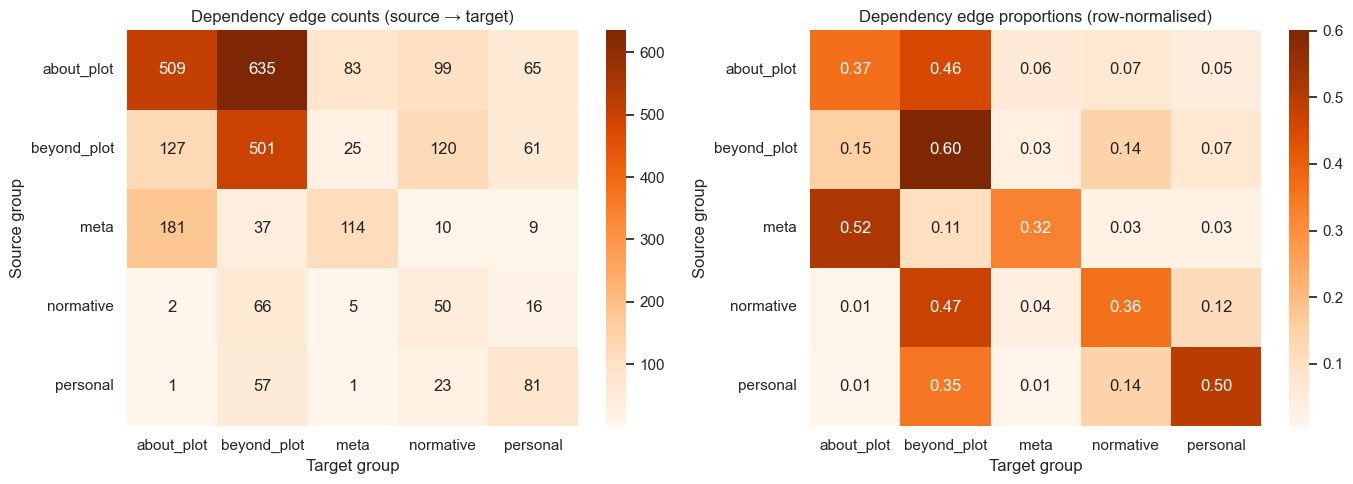

In [37]:
edge_mat = pd.DataFrame(0, index=all_groups, columns=all_groups, dtype=int)
for _, row in edges_df.iterrows():
    edge_mat.loc[row["src_group"], row["tgt_group"]] += 1

edge_prob = edge_mat.div(edge_mat.sum(axis=1).replace(0, np.nan), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(edge_mat, annot=True, fmt="d", cmap="Oranges", ax=axes[0])
axes[0].set_title("Dependency edge counts (source → target)")
axes[0].set_xlabel("Target group")
axes[0].set_ylabel("Source group")

sns.heatmap(edge_prob, annot=True, fmt=".2f", cmap="Oranges", ax=axes[1])
axes[1].set_title("Dependency edge proportions (row-normalised)")
axes[1].set_xlabel("Target group")
axes[1].set_ylabel("Source group")

plt.tight_layout()
plt.show()

In [38]:
# Key directional ratios
bu = edge_mat.loc["about_plot", "beyond_plot"] if "about_plot" in edge_mat.index and "beyond_plot" in edge_mat.columns else 0
td = edge_mat.loc["beyond_plot", "about_plot"] if "beyond_plot" in edge_mat.index and "about_plot" in edge_mat.columns else 0
print(f"Bottom-up edges (about_plot → beyond_plot): {bu}")
print(f"Top-down edges  (beyond_plot → about_plot): {td}")
print(f"Ratio bottom-up / top-down: {bu / max(td, 1):.2f}")
print()

# Edges terminating in normative
if "normative" in edge_mat.columns:
    norm_incoming = edge_mat["normative"]
    print("Edges terminating in normative by source group:")
    print(norm_incoming.to_string())

Bottom-up edges (about_plot → beyond_plot): 635
Top-down edges  (beyond_plot → about_plot): 127
Ratio bottom-up / top-down: 5.00

Edges terminating in normative by source group:
about_plot      99
beyond_plot    120
meta            10
normative       50
personal        23


## 4 — Node roles: in-degree / out-degree by group (is normative an L5 sink?)

In [39]:
role_stats = nodes_df.groupby("group").agg(
    mean_in=pd.NamedAgg(column="in_degree", aggfunc="mean"),
    mean_out=pd.NamedAgg(column="out_degree", aggfunc="mean"),
    median_in=pd.NamedAgg(column="in_degree", aggfunc="median"),
    median_out=pd.NamedAgg(column="out_degree", aggfunc="median"),
    n=pd.NamedAgg(column="node_id", aggfunc="count"),
    frac_sink=pd.NamedAgg(column="out_degree", aggfunc=lambda s: (s == 0).mean()),
    frac_root=pd.NamedAgg(column="in_degree", aggfunc=lambda s: (s == 0).mean()),
).round(3)

role_stats

,mean_in,mean_out,median_in,median_out,n,frac_sink,frac_root
group,,,,,,,
about_plot,0.877,0.877,1.0,1.0,935,0.353,0.353
beyond_plot,1.203,1.203,1.0,1.0,1077,0.245,0.245
meta,0.738,0.738,0.0,0.0,309,0.547,0.547
normative,1.589,1.589,1.0,1.0,190,0.147,0.147
personal,1.184,1.184,1.0,1.0,196,0.281,0.281


In [40]:
chart_in = alt.Chart(nodes_df).mark_boxplot().encode(
    x=alt.X("group:N", sort=GROUPS, title=None),
    y=alt.Y("in_degree:Q", title="In-degree"),
).properties(title="In-degree by functional group", width=350, height=250)

chart_out = alt.Chart(nodes_df).mark_boxplot().encode(
    x=alt.X("group:N", sort=GROUPS, title=None),
    y=alt.Y("out_degree:Q", title="Out-degree"),
).properties(title="Out-degree by functional group", width=350, height=250)

chart_in | chart_out

alt.HConcatChart(...)

## 5 — Attachment and distance-to-plot

For every `beyond_plot` and `normative` node, how far is the nearest `about_plot` node in the undirected dependency graph?

In [41]:
distance_rows = []

for c in comments:
    ci = c["comment_index"]
    dep_graph = c.get("dependency_graph") or []
    if not dep_graph:
        continue

    G = nx.Graph()
    node_grp = {}
    for n in dep_graph:
        nid = n["id"]
        grp = to_group(n.get("comment_tag"))
        G.add_node(nid)
        node_grp[nid] = grp
    for n in dep_graph:
        for dep in n.get("depends_on") or []:
            G.add_edge(dep, n["id"])

    about_nodes = {nid for nid, g in node_grp.items() if g == "about_plot"}
    if not about_nodes:
        for nid, g in node_grp.items():
            if g in ("beyond_plot", "normative"):
                distance_rows.append({"comment_index": ci, "node_id": nid, "group": g, "dist_to_plot": np.inf})
        continue

    for nid, g in node_grp.items():
        if g not in ("beyond_plot", "normative"):
            continue
        dists = []
        for ap in about_nodes:
            try:
                d = nx.shortest_path_length(G, source=nid, target=ap)
            except nx.NetworkXNoPath:
                d = np.inf
            dists.append(d)
        distance_rows.append({"comment_index": ci, "node_id": nid, "group": g, "dist_to_plot": min(dists)})

dist_df = pd.DataFrame(distance_rows)
print(f"{len(dist_df)} beyond_plot/normative nodes")
dist_df["dist_to_plot"].replace(np.inf, np.nan).describe().round(2)

1267 beyond_plot/normative nodes


count    984.00
mean       1.66
std        0.89
min        1.00
25%        1.00
50%        1.00
75%        2.00
max        6.00
Name: dist_to_plot, dtype: float64

In [42]:
finite = dist_df[dist_df["dist_to_plot"] < np.inf]
anchored_frac = len(finite) / max(len(dist_df), 1)
print(f"Fraction of beyond_plot/normative nodes reachable from about_plot: {anchored_frac:.3f}")

if not finite.empty:
    max_dist = int(finite["dist_to_plot"].max()) + 1
    alt.Chart(finite).mark_bar(opacity=0.6).encode(
        x=alt.X("dist_to_plot:Q", bin=alt.Bin(step=1, extent=[0, max_dist]),
                 title="Shortest-path distance to nearest about_plot node"),
        y=alt.Y("count()", title="Count"),
        color=alt.Color("group:N"),
    ).properties(
        title="Distance-to-plot for beyond_plot and normative nodes",
        width=500, height=300,
    ).display()

Fraction of beyond_plot/normative nodes reachable from about_plot: 0.777


alt.Chart(...)

## 6 — Comment-level integration strategies

For each comment, compute a small feature vector summarising its integration style, then look at clusters of strategies.

In [43]:
comment_features = []

for c in comments:
    ci = c["comment_index"]
    dep_graph = c.get("dependency_graph") or []
    if not dep_graph:
        continue

    grps = [to_group(n.get("comment_tag")) for n in sorted(dep_graph, key=lambda n: n["id"])]
    n_sent = len(grps)
    grp_counts = Counter(grps)

    # Proportions
    props = {f"prop_{g}": grp_counts.get(g, 0) / n_sent for g in GROUPS}

    # Edges
    nodes_by_id = {n["id"]: to_group(n.get("comment_tag")) for n in dep_graph}
    bu_edges = 0  # about_plot → beyond_plot
    td_edges = 0  # beyond_plot → about_plot
    to_norm = 0   # * → normative
    total_edges = 0
    for n in dep_graph:
        tgt = nodes_by_id.get(n["id"], "unknown")
        for dep in n.get("depends_on") or []:
            src = nodes_by_id.get(dep, "unknown")
            total_edges += 1
            if src == "about_plot" and tgt == "beyond_plot":
                bu_edges += 1
            if src == "beyond_plot" and tgt == "about_plot":
                td_edges += 1
            if tgt == "normative":
                to_norm += 1

    # Whether normative nodes are all terminal (out-degree 0 within the comment subgraph)
    norm_nodes = [n for n in dep_graph if to_group(n.get("comment_tag")) == "normative"]
    # out-degree = number of other nodes that depend on this one
    depended_on_set = set()
    for n in dep_graph:
        depended_on_set.update(n.get("depends_on") or [])
    frac_norm_terminal = (
        sum(1 for n in norm_nodes if n["id"] not in depended_on_set) / max(len(norm_nodes), 1)
    )

    # Sequence diversity: Shannon entropy of bigram transitions
    bigrams = Counter()
    for a, b in zip(grps, grps[1:]):
        bigrams[(a, b)] += 1
    total_bg = sum(bigrams.values())
    if total_bg > 0:
        probs = np.array(list(bigrams.values())) / total_bg
        seq_entropy = float(-np.sum(probs * np.log2(probs + 1e-12)))
    else:
        seq_entropy = 0.0

    comment_features.append({
        "comment_index": ci,
        "n_sentences": n_sent,
        "n_edges": total_edges,
        **props,
        "bu_edges": bu_edges,
        "td_edges": td_edges,
        "to_norm_edges": to_norm,
        "frac_norm_terminal": frac_norm_terminal,
        "seq_entropy": seq_entropy,
    })

feat_df = pd.DataFrame(comment_features)
feat_df.describe().round(3)

,comment_index,n_sentences,n_edges,prop_about_plot,prop_beyond_plot,prop_normative,prop_personal,prop_meta,bu_edges,td_edges,to_norm_edges,frac_norm_terminal,seq_entropy
count,153.000,153.000,153.000,153.000,153.000,153.000,153.000,153.000,153.000,153.000,153.000,153.000,153.000
mean,77.000,17.693,18.810,0.333,0.388,0.081,0.081,0.117,4.150,0.830,1.974,0.264,2.363
std,44.311,8.650,13.296,0.166,0.176,0.129,0.099,0.148,5.168,2.124,2.918,0.388,0.680
min,1.000,2.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.000
25%,39.000,10.000,9.000,0.231,0.273,0.000,0.000,0.048,1.000,0.000,0.000,0.000,2.128
50%,77.000,17.000,17.000,0.344,0.379,0.037,0.056,0.083,3.000,0.000,0.000,0.000,2.436
75%,115.000,23.000,24.000,0.444,0.500,0.120,0.125,0.125,6.000,1.000,3.000,0.500,2.726
max,153.000,42.000,88.000,0.833,0.875,1.000,0.500,1.000,51.000,19.000,12.000,1.000,3.788


In [44]:
hist_a = alt.Chart(feat_df).mark_bar(color="steelblue").encode(
    x=alt.X("prop_about_plot:Q", bin=alt.Bin(maxbins=20)),
    y=alt.Y("count()", title="# comments"),
).properties(title="prop about_plot", width=250, height=200)

hist_b = alt.Chart(feat_df).mark_bar(color="coral").encode(
    x=alt.X("prop_beyond_plot:Q", bin=alt.Bin(maxbins=20)),
    y=alt.Y("count()", title="# comments"),
).properties(title="prop beyond_plot", width=250, height=200)

hist_c = alt.Chart(feat_df).mark_bar(color="goldenrod").encode(
    x=alt.X("prop_normative:Q", bin=alt.Bin(maxbins=20)),
    y=alt.Y("count()", title="# comments"),
).properties(title="prop normative", width=250, height=200)

hist_d = alt.Chart(feat_df).mark_bar(color="mediumseagreen").encode(
    x=alt.X("seq_entropy:Q", bin=alt.Bin(maxbins=20)),
    y=alt.Y("count()", title="# comments"),
).properties(title="Sequence entropy (integration diversity)", width=250, height=200)

lim = float(max(feat_df["bu_edges"].max(), feat_df["td_edges"].max()) + 1)
diag_df = pd.DataFrame({"x": [0, lim], "y": [0, lim]})
scatter_e = (
    alt.Chart(feat_df).mark_circle(opacity=0.4).encode(
        x=alt.X("bu_edges:Q", title="Bottom-up edges"),
        y=alt.Y("td_edges:Q", title="Top-down edges"),
    )
    + alt.Chart(diag_df).mark_line(strokeDash=[5, 5], color="grey").encode(
        x="x:Q", y="y:Q",
    )
).properties(title="Bottom-up vs top-down (per comment)", width=250, height=200)

hist_f = alt.Chart(feat_df).mark_bar(color="plum").encode(
    x=alt.X("frac_norm_terminal:Q", bin=alt.Bin(maxbins=20)),
    y=alt.Y("count()", title="# comments"),
).properties(title="Fraction normative nodes that are sinks", width=250, height=200)

(hist_a | hist_b | hist_c) & (hist_d | scatter_e | hist_f)

alt.VConcatChart(...)

### 6.1 K-means comment-strategy clustering

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

cluster_cols = [c for c in feat_df.columns if c not in ("comment_index",)]
X = feat_df[cluster_cols].fillna(0).values
X_scaled = StandardScaler().fit_transform(X)

km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_scaled)
feat_df["strategy_cluster"] = km.labels_

pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
feat_df["pc1"] = pca[:, 0]
feat_df["pc2"] = pca[:, 1]

alt.Chart(feat_df).mark_circle(opacity=0.6, size=30).encode(
    x=alt.X("pc1:Q", title="PC 1"),
    y=alt.Y("pc2:Q", title="PC 2"),
    color=alt.Color("strategy_cluster:N", title="Cluster",
                     scale=alt.Scale(scheme="tableau10")),
).properties(title="Comment-level strategy clusters (PCA)", width=500, height=350)

alt.Chart(...)

In [46]:
# Cluster profiles
profile = feat_df.groupby("strategy_cluster")[cluster_cols].mean().round(3)
profile

,n_sentences,n_edges,prop_about_plot,prop_beyond_plot,prop_normative,prop_personal,prop_meta,bu_edges,td_edges,to_norm_edges,frac_norm_terminal,seq_entropy
strategy_cluster,,,,,,,,,,,,
0,13.792,13.014,0.361,0.418,0.021,0.104,0.096,3.972,0.514,0.264,0.000,2.316
1,9.818,8.000,0.091,0.119,0.250,0.061,0.479,0.091,0.273,0.364,0.424,1.022
2,30.850,42.300,0.416,0.408,0.035,0.061,0.080,10.000,3.400,2.350,0.045,2.588
3,19.780,20.140,0.313,0.395,0.149,0.060,0.083,2.960,0.380,4.640,0.696,2.637


## 7 — Bayesian multilevel models

The analyses above treat all comments as exchangeable. But comments come from different people and have different lengths. Bayesian multilevel (hierarchical) models let us:

1. **Separate within-comment from between-comment variation** in group proportions.
2. **Estimate transition probabilities** with partial pooling across comments.
3. **Estimate the prevalence of bottom-up vs top-down edges** with proper uncertainty.

We use **PyMC** below. Install with `pip install pymc arviz` if needed.

### 7.1 Bayesian Dirichlet-Multinomial model for group proportions

**Model**: Each comment $i$ has $n_i$ sentences. Their group counts $\mathbf{y}_i$ are drawn from a Multinomial whose probability vector $\boldsymbol{\theta}_i$ is itself drawn from a shared Dirichlet prior:

$$
\boldsymbol{\alpha} \sim \text{Exponential}(1) \quad (\text{one per group}) \\
\boldsymbol{\theta}_i \sim \text{Dirichlet}(\boldsymbol{\alpha}) \\
\mathbf{y}_i \sim \text{Multinomial}(n_i, \boldsymbol{\theta}_i)
$$

The Dirichlet concentration $\boldsymbol{\alpha}$ captures the *population-level* tendency across all comments, while each $\boldsymbol{\theta}_i$ captures a *comment-specific* proportion.

In [47]:
import pymc as pm
import arviz as az

# Build count matrix: rows = comments, columns = functional groups
count_mat = (
    nodes_df.groupby(["comment_index", "group"]).size()
    .unstack(fill_value=0)
    .reindex(columns=GROUPS, fill_value=0)
)
Y = count_mat.values.astype(int)
N = Y.sum(axis=1)
K = Y.shape[1]
n_comments_model = Y.shape[0]
print(f"Fitting Dirichlet-Multinomial: {n_comments_model} comments, {K} groups")

ModuleNotFoundError: No module named 'pymc'

In [ ]:
with pm.Model() as dm_model:
    alpha = pm.Exponential("alpha", lam=0.5, shape=K)
    theta = pm.Dirichlet("theta", a=alpha, shape=(n_comments_model, K))
    obs = pm.Multinomial("obs", n=N, p=theta, observed=Y)

    dm_trace = pm.sample(1000, tune=1000, cores=2, random_seed=42, progressbar=True)

In [ ]:
# Posterior of population-level concentration (alpha)
alpha_post = dm_trace.posterior["alpha"]
alpha_means = alpha_post.mean(dim=["chain", "draw"]).values
alpha_total = alpha_means.sum()
expected_props = alpha_means / alpha_total

print("Population-level expected proportions (from Dirichlet alpha):")
for g, p in zip(GROUPS, expected_props):
    print(f"  {g:20s}  {p:.3f}")
print(f"\nDirichlet concentration (sum of alpha): {alpha_total:.2f}")
print("  (Higher = less between-comment variation; lower = more heterogeneity)")

In [ ]:
az.plot_posterior(dm_trace, var_names=["alpha"], figsize=(14, 3))
plt.suptitle("Posterior of Dirichlet concentration parameters (alpha)", y=1.02)
plt.tight_layout()
plt.show()

**Interpretation**: A low total $\sum \alpha$ (< 5) means comments are very heterogeneous in their group mixtures; a high value (> 20) means they are similar. The per-group $\alpha_k / \sum \alpha$ gives the population-level expected proportion of each group.

### 7.2 Bayesian hierarchical transition model

For each row of the transition matrix (i.e. each "current" group), the distribution over "next" groups is modelled as:

$$
\boldsymbol{\pi}_g \sim \text{Dirichlet}(\boldsymbol{\beta}_g)
$$

where $\boldsymbol{\beta}_g$ is a learned Dirichlet concentration.

We fit this at the population level (pooled across comments) to get credible intervals on each transition probability.

In [ ]:
# Build transition count matrix from earlier
trans_groups_ordered = [g for g in GROUPS if g in trans_mat.index]
T = trans_mat.reindex(index=trans_groups_ordered, columns=trans_groups_ordered, fill_value=0).values

with pm.Model() as trans_model:
    beta = pm.Exponential("beta", lam=0.5, shape=(len(trans_groups_ordered), len(trans_groups_ordered)))
    for i, src in enumerate(trans_groups_ordered):
        row_total = int(T[i].sum())
        if row_total == 0:
            continue
        pi = pm.Dirichlet(f"pi_{src}", a=beta[i] + 0.5, shape=len(trans_groups_ordered))
        pm.Multinomial(f"obs_{src}", n=row_total, p=pi, observed=T[i])

    trans_trace = pm.sample(1000, tune=1000, cores=2, random_seed=42, progressbar=True)

In [ ]:
fig, axes = plt.subplots(len(trans_groups_ordered), 1, figsize=(10, 3 * len(trans_groups_ordered)))
if len(trans_groups_ordered) == 1:
    axes = [axes]

for i, src in enumerate(trans_groups_ordered):
    varname = f"pi_{src}"
    if varname not in trans_trace.posterior:
        continue
    post = trans_trace.posterior[varname].values.reshape(-1, len(trans_groups_ordered))
    means = post.mean(axis=0)
    ci_lo = np.percentile(post, 2.5, axis=0)
    ci_hi = np.percentile(post, 97.5, axis=0)

    x = np.arange(len(trans_groups_ordered))
    axes[i].bar(x, means, color="steelblue", alpha=0.7)
    axes[i].errorbar(x, means, yerr=[means - ci_lo, ci_hi - means], fmt="none", color="black", capsize=3)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(trans_groups_ordered, rotation=45, ha="right")
    axes[i].set_title(f"Transition from '{src}' → (95% CI)")
    axes[i].set_ylabel("Probability")

plt.tight_layout()
plt.show()

### 7.3 Bayesian model of bottom-up vs top-down edge rates (within / between comments)

For each comment $i$, let $b_i$ = # bottom-up edges (about_plot → beyond_plot) and $t_i$ = # top-down edges (beyond_plot → about_plot). Conditional on $d_i = b_i + t_i$ total cross-group edges, $b_i$ follows a Binomial with comment-specific probability $\phi_i$:

$$
\mu \sim \text{Beta}(2, 2) \\
\kappa \sim \text{HalfNormal}(10) \\
\phi_i \sim \text{Beta}(\mu \kappa,\; (1 - \mu) \kappa) \\
b_i \sim \text{Binomial}(d_i,\; \phi_i)
$$

Here $\mu$ is the population-level probability of an edge being bottom-up (vs top-down), and $\kappa$ controls how much comments vary around that.

In [ ]:
bu_td = feat_df[["comment_index", "bu_edges", "td_edges"]].copy()
bu_td["total_cross"] = bu_td["bu_edges"] + bu_td["td_edges"]
# Only keep comments with at least 1 cross-group edge
bu_td_pos = bu_td[bu_td["total_cross"] > 0].reset_index(drop=True)

print(f"{len(bu_td_pos)} comments with >= 1 cross-group edge")
bu_td_pos[["bu_edges", "td_edges", "total_cross"]].describe().round(2)

In [ ]:
b_obs = bu_td_pos["bu_edges"].values.astype(int)
d_obs = bu_td_pos["total_cross"].values.astype(int)
J = len(b_obs)

with pm.Model() as butd_model:
    mu = pm.Beta("mu", alpha=2, beta=2)  # population BU probability
    kappa = pm.HalfNormal("kappa", sigma=10)  # between-comment dispersion

    phi = pm.Beta("phi", alpha=mu * kappa, beta=(1 - mu) * kappa, shape=J)
    pm.Binomial("b", n=d_obs, p=phi, observed=b_obs)

    butd_trace = pm.sample(1000, tune=1000, cores=2, random_seed=42, progressbar=True)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

az.plot_posterior(butd_trace, var_names=["mu"], ax=axes[0], ref_val=0.5)
axes[0].set_title("Population BU probability μ\n(>0.5 = bottom-up dominant)")

az.plot_posterior(butd_trace, var_names=["kappa"], ax=axes[1])
axes[1].set_title("Between-comment dispersion κ\n(higher = less variation)")

plt.tight_layout()
plt.show()

In [ ]:
# Shrinkage plot: raw BU fraction vs posterior mean of phi_i
phi_post = butd_trace.posterior["phi"].mean(dim=["chain", "draw"]).values
raw_frac = b_obs / d_obs

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(raw_frac, phi_post, alpha=0.4, s=20)
ax.plot([0, 1], [0, 1], "--", color="grey", lw=0.8)
mu_post_mean = float(butd_trace.posterior["mu"].mean())
ax.axhline(mu_post_mean, color="red", ls=":", lw=1, label=f"population μ = {mu_post_mean:.2f}")
ax.set_xlabel("Raw BU fraction (b / (b+t))")
ax.set_ylabel("Posterior mean φ_i")
ax.set_title("Bayesian shrinkage of per-comment BU probability")
ax.legend()
plt.tight_layout()
plt.show()

### 7.4 Bayesian hierarchical model of normative sink probability

Is the normative (L5) layer truly a terminal sink? For each comment with at least one normative node, let $s_i$ = # normative nodes with out-degree 0 (sinks), out of $m_i$ total normative nodes.

$$
\mu_s \sim \text{Beta}(2, 2) \\
\kappa_s \sim \text{HalfNormal}(10) \\
\psi_i \sim \text{Beta}(\mu_s \kappa_s,\; (1 - \mu_s) \kappa_s) \\
s_i \sim \text{Binomial}(m_i,\; \psi_i)
$$

In [ ]:
norm_sink_rows = []
for c in comments:
    dep_graph = c.get("dependency_graph") or []
    depended_on = set()
    for n in dep_graph:
        depended_on.update(n.get("depends_on") or [])
    norm_nodes = [n for n in dep_graph if to_group(n.get("comment_tag")) == "normative"]
    if not norm_nodes:
        continue
    m = len(norm_nodes)
    s = sum(1 for n in norm_nodes if n["id"] not in depended_on)
    norm_sink_rows.append({"comment_index": c["comment_index"], "m": m, "s": s})

ns_df = pd.DataFrame(norm_sink_rows)
print(f"{len(ns_df)} comments with normative nodes")
print(f"Overall sink rate: {ns_df['s'].sum() / ns_df['m'].sum():.3f}")

In [ ]:
s_obs = ns_df["s"].values.astype(int)
m_obs = ns_df["m"].values.astype(int)
J_ns = len(s_obs)

with pm.Model() as norm_sink_model:
    mu_s = pm.Beta("mu_s", alpha=2, beta=2)
    kappa_s = pm.HalfNormal("kappa_s", sigma=10)

    psi = pm.Beta("psi", alpha=mu_s * kappa_s, beta=(1 - mu_s) * kappa_s, shape=J_ns)
    pm.Binomial("s", n=m_obs, p=psi, observed=s_obs)

    ns_trace = pm.sample(1000, tune=1000, cores=2, random_seed=42, progressbar=True)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

az.plot_posterior(ns_trace, var_names=["mu_s"], ax=axes[0], ref_val=0.5)
axes[0].set_title("Population normative-sink probability μ_s\n(high = normative is truly terminal / L5)")

az.plot_posterior(ns_trace, var_names=["kappa_s"], ax=axes[1])
axes[1].set_title("Between-comment dispersion κ_s")

plt.tight_layout()
plt.show()

### 7.5 Bayesian hierarchical model of within-comment integration diversity

We model the per-comment **number of distinct functional groups** (a proxy for "integration breadth") as a function of comment length, with partial pooling.

$$
\text{diversity}_i \sim \text{Normal}(\alpha_0 + \beta_1 \cdot \log(n_i),\; \sigma)
$$

This tells us whether longer comments tend to integrate more groups, and how much unexplained variation remains.

In [ ]:
div_rows = []
for c in comments:
    dep_graph = c.get("dependency_graph") or []
    if not dep_graph:
        continue
    groups_present = {to_group(n.get("comment_tag")) for n in dep_graph}
    groups_present.discard("unknown")
    div_rows.append({
        "comment_index": c["comment_index"],
        "n_sentences": len(dep_graph),
        "n_groups": len(groups_present),
    })

div_df = pd.DataFrame(div_rows)
div_df["log_n"] = np.log(div_df["n_sentences"])

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(div_df["n_sentences"], div_df["n_groups"], alpha=0.3, s=15)
ax.set_xlabel("# ACE sentences")
ax.set_ylabel("# distinct functional groups")
ax.set_title("Integration breadth vs comment length")
plt.tight_layout()
plt.show()

In [ ]:
with pm.Model() as div_model:
    a0 = pm.Normal("a0", mu=2, sigma=2)
    b1 = pm.Normal("b1", mu=0, sigma=2)
    sigma = pm.HalfNormal("sigma", sigma=2)

    mu_div = a0 + b1 * div_df["log_n"].values
    pm.Normal("diversity", mu=mu_div, sigma=sigma, observed=div_df["n_groups"].values.astype(float))

    div_trace = pm.sample(1000, tune=1000, cores=2, random_seed=42, progressbar=True)

In [ ]:
az.plot_posterior(div_trace, var_names=["a0", "b1", "sigma"], figsize=(14, 3))
plt.suptitle("Regression: n_groups ~ a0 + b1 * log(n_sentences)", y=1.04)
plt.tight_layout()
plt.show()

b1_samples = div_trace.posterior["b1"].values.flatten()
print(f"P(b1 > 0) = {(b1_samples > 0).mean():.3f}")
print(f"  → Longer comments {'do' if (b1_samples > 0).mean() > 0.95 else 'may not'} reliably integrate more groups.")

## 8 — Summary table

Collects key numbers for the paper.

In [ ]:
total_nodes = len(nodes_df)
total_edges = len(edges_df)
total_comments = len(comments)

bu_total = int(edge_mat.loc["about_plot", "beyond_plot"]) if "about_plot" in edge_mat.index and "beyond_plot" in edge_mat.columns else 0
td_total = int(edge_mat.loc["beyond_plot", "about_plot"]) if "beyond_plot" in edge_mat.index and "about_plot" in edge_mat.columns else 0

summary = pd.DataFrame([
    ("Total comments", total_comments),
    ("Total ACE sentences (nodes)", total_nodes),
    ("Total dependency edges", total_edges),
    ("About-plot sentences", int(grp_cts.get("about_plot", 0))),
    ("Beyond-plot sentences", int(grp_cts.get("beyond_plot", 0))),
    ("Normative sentences", int(grp_cts.get("normative", 0))),
    ("Personal sentences", int(grp_cts.get("personal", 0))),
    ("Meta sentences", int(grp_cts.get("meta", 0))),
    ("Bottom-up edges (about→beyond)", bu_total),
    ("Top-down edges (beyond→about)", td_total),
    ("BU/TD ratio", round(bu_total / max(td_total, 1), 2)),
    ("Bayesian μ (BU probability)", round(float(butd_trace.posterior['mu'].mean()), 3)),
    ("Bayesian μ_s (normative sink probability)", round(float(ns_trace.posterior['mu_s'].mean()), 3)),
    ("Frac beyond/norm nodes reachable from about_plot", round(anchored_frac, 3)),
], columns=["Metric", "Value"])

summary